<a href="https://colab.research.google.com/github/SonalGire/AgenticAI-using-LangGraph/blob/main/Iterative_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [63]:
!pip install langchain langgraph langchain-openai

In [64]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from pydantic import BaseModel, Field
from langchain.messages import HumanMessage, AIMessage, SystemMessage
import operator

In [65]:

AZURE_OPENAI_API_KEY="ewrsfdgcv57Q7t7R80"
AZURE_OPENAI_ENDPOINT: str = "https:/"

LLM = "gpt"
LLM_MODEL="gpt-4"
API_VERSION: str = "2026"


In [66]:

from langchain_openai import AzureOpenAIEmbeddings, AzureChatOpenAI

# LLM Instances
llm = AzureChatOpenAI(
    azure_deployment=LLM,
    api_version=API_VERSION,
    temperature=0.7,
    api_key=AZURE_OPENAI_API_KEY,
    azure_endpoint=AZURE_OPENAI_ENDPOINT,
    streaming=False
)

# LLM Instances
llm_evaluate = AzureChatOpenAI(
    azure_deployment=LLM_MODEL,
    api_version=API_VERSION,
    temperature=0.7,
    api_key=AZURE_OPENAI_API_KEY,
    azure_endpoint=AZURE_OPENAI_ENDPOINT,
    streaming=False
)

In [67]:
generator_llm = llm
evaluator_llm = llm_evaluate
optimizer_llm = llm

In [68]:
class TweetState(TypedDict):
  topic: str
  tweet: str
  evaluation : Literal['approved','needs_improvement']
  feedback: str
  iteration:  int
  max_iteration: int

  tweet_history: Annotated[list[str], operator.add]
  feedback_history: Annotated[list[str], operator.add]


In [69]:
class TweetEvaluation(BaseModel):
  evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result")
  feedback: str = Field(..., description="feedback for the tweet.")

In [70]:
structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation)

In [71]:
def generate_content(state: TweetState):
  topic = state['topic']
  messages = [
      SystemMessage(content="You are a funny and clever Twitter/X influencer."),
      HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{topic}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""") ]

  response = generator_llm.invoke(messages).content

  return {'tweet': response, 'tweet_history':[response]}


In [72]:
def evaluate_content(state: TweetState):
  tweet = state['tweet']
  messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{tweet}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?
2. Humor – Did it genuinely make you smile, laugh, or chuckle?
3. Punchiness – Is it short, sharp, and scroll-stopping?
4. Virality Potential – Would people retweet or share it?
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"
- feedback: One paragraph explaining the strengths and weaknesses
""") ]

  response = structured_evaluator_llm.invoke(messages)

  return {'evaluation': response.evaluation, 'feedback':response.feedback}

In [73]:
def optimize_content(state: TweetState):
  messages = [
      SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
      HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")]

  response = optimizer_llm.invoke(messages).content
  iteration = state['iteration'] + 1

  return {'tweet': response, 'iteration':iteration, 'tweet_history': [response]}


In [74]:
def route_evaluation(state: TweetState):

  if state['evaluation'] == 'approved'or state['iteration'] >= state['max_iteration']:
    return 'approved'
  else:
    return 'needs_improvement'

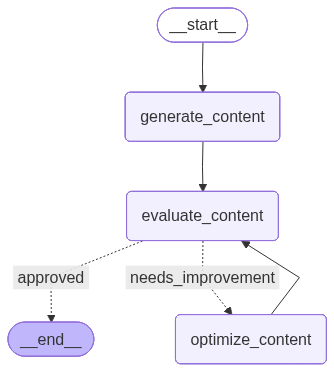

In [75]:
graph = StateGraph(TweetState)

graph.add_node("generate_content", generate_content)
graph.add_node("evaluate_content", evaluate_content)
graph.add_node("optimize_content", optimize_content)

graph.add_edge(START,'generate_content')
graph.add_edge('generate_content','evaluate_content')
graph.add_conditional_edges('evaluate_content', route_evaluation, {'approved':END,'needs_improvement': 'optimize_content'})

graph.add_edge('optimize_content', 'evaluate_content')

graph.compile()

In [85]:
workflow = graph.compile()
initial_state = {'topic':'Indian Railways',
                 'iteration':1,
                 'max_iteration':5}
response = workflow.invoke(initial_state)
print(f"Topic:{response['topic']}")
print(f"\n\n  Tweet:\n\n {response['tweet']}\n")
print("-"*50)
print(f"\n\n Iteration:{response['iteration']}")
print(f"\n Max iteration:{response['max_iteration']}")
print(f"\n\n  Tweet history:\n\n {response['tweet_history']}")
print(f"\n\n  Feedback history:{response['feedback_history']}")


/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=TweetEvaluation(evaluatio...pace of similar jokes.'), input_type=TweetEvaluation])
  return self.__pydantic_serializer__.to_python(


Topic:

 Indian Railways


  Tweet:

 Indian Railways: The train’s ETA is a mystery, but that chaiwala finds you like a heat-seeking missile every single time. Legends only. 🚂☕

--------------------------------------------------


 Iteration:2

 Max iteration:5


  Tweet history:

 ['Indian Railways: Where the train is always late, but the chai guy is always on time. Priorities sorted. 🚂☕', 'Indian Railways: The train’s ETA is a mystery, but that chaiwala finds you like a heat-seeking missile every single time. Legends only. 🚂☕']


  Feedback history:[]


/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=TweetEvaluation(evaluatio...the criteria provided.'), input_type=TweetEvaluation])
  return self.__pydantic_serializer__.to_python(
